# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [2]:
df_cleaned = pd.read_csv("zillow_cleaned.csv")

# ensure we have no NAs for models to work
df_cleaned = df_cleaned.dropna()

# drop propertyzoningdesc and propertycountylandusecode because they have too many unique string values. It could be encoded, but we decided against that.
df_cleaned = df_cleaned.drop(columns=['propertyzoningdesc', 'propertycountylandusecode'])

# drop these features since they are redundant to other bathroom and squarefeet features with near perfect positive correlations
df_cleaned = df_cleaned.drop(columns=['bathroomcnt', 'fullbathcnt', 'finishedsquarefeet12'])

random_state = 42

In [3]:
X = df_cleaned.drop(columns=['taxvaluedollarcnt'])
y = df_cleaned['taxvaluedollarcnt']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [5]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

In [15]:
from sklearn.model_selection import cross_validate

#### Ridge Regression - Baseline

In [ ]:
# Ridge Regression
# Use cross_validate instead of cross_val_score so we can compare mean training and validation scores for all folds to check for overfitting

ridge_model = Ridge(random_state=random_state)
ridge_scores = cross_validate(ridge_model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

ridge_mean_train_mae = np.mean(-ridge_scores['train_score'])
ridge_mean_mae = np.mean(-ridge_scores['test_score'])
ridge_std_mae = np.std(-ridge_scores['test_score'])

print(f"Mean Train MAE Score: ${ridge_mean_train_mae:,.2f}")
print(f"Mean CV MAE Score: ${ridge_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${ridge_std_mae:,.2f}")


Mean Train MAE Score: $209,045.50
Mean CV MAE Score: $236,831.33
STD CV MAE Score: $47,231.01


#### Random Forest - Baseline

In [7]:
# Random Forest
# Use cross_validate instead of cross_val_score so we can compare mean training and validation scores for all folds to check for overfitting

forest_model = RandomForestRegressor(random_state=random_state)
forest_scores = cross_validate(forest_model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

forest_mean_train_mae = np.mean(-forest_scores['train_score'])
forest_mean_mae = np.mean(-forest_scores['test_score'])
forest_std_mae = np.std(-forest_scores['test_score'])

print(f"Mean Train MAE Score: ${forest_mean_train_mae:,.2f}")
print(f"Mean CV MAE Score: ${forest_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${forest_std_mae:,.2f}")

Mean Train MAE Score: $69,031.64
Mean CV MAE Score: $184,979.41
STD CV MAE Score: $11,173.44


#### Gradient Boosting Trees - Baseline

In [8]:
# Gradient Boosting Trees
# Use cross_validate instead of cross_val_score so we can compare mean training and validation scores for all folds to check for overfitting

boosting_model = GradientBoostingRegressor(random_state=random_state)
boosting_scores = cross_validate(boosting_model, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

boosting_mean_train_mae = np.mean(-boosting_scores['train_score'])
boosting_mean_mae = np.mean(-boosting_scores['test_score'])
boosting_std_mae = np.std(-boosting_scores['test_score'])

print(f"Mean Train MAE Score: ${boosting_mean_train_mae:,.2f}")
print(f"Mean CV MAE Score: ${boosting_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${boosting_std_mae:,.2f}")

Mean Train MAE Score: $147,718.04
Mean CV MAE Score: $185,165.87
STD CV MAE Score: $10,869.67


### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

####    **Part 1 Discussion:**

- **Which model performed best overall?**
    - By Mean CV MAE Score, the Random Forest Baseline Model performed best as it produced the lowest score of the three models at 184,979.41. However, the Mean Train MAE Score across all folds for the Random Forest Baseline Model is 69,031.64, which is significantly lower than the validation score. The large difference in training and validation scores is an indication that the model is overfitting the training data and likely will not generalize well to new data.
  
    - The Gradient Boosting Trees Baseline Model produced a similar Mean CV MAE Score of 185,165.87 but has a Mean Train MAE Score of 147,718.04, which is much closer to the validation score and an indication that the model will generalize better. Thus, despite its MEAN CV MAE Score being slightly higher than that of the Random Forest Baseline Model, the Gradient Boosting Trees Baseline Model performed the best overall.

- **Which model was the most stable?**
    - Comparing the standard deviations of the three models, the Gradient Boosting Trees Baseline Model was the most stable with a STD CV MAE of 10,869.67, which is only about 6% of the mean. The Random Forest Baseline Model was only slightly behind with a STD CV MAE of 11,173.44, also only 6% of the mean, while the Ridge Regression Baseline Model was still reasonably okay but much less stable with a STD CV MAE of 47,231.01, which is about 20% of the mean.

- **Any signs of overfitting or underfitting?**
    - The Ridge Regression Baseline Model has a Mean Train MAE Score of 209,045.50, which means the validation error of 236,831.33 is around 13% higher than the training error. This difference is not too large, so while there may be some mild overfitting, the model generally seems to be working moderately well.

    - As mentioned above, the Random Forest Baseline Model is overfitting the training data as the Mean CV MAE Score of 184,979.41 shows that the validation error is 168% higher than the Mean Train MAE Score of 69,031.64.

    - The Gradient Boosting Trees Baseline Model has Mean CV and Mean Train scores of 185,165.87 and 147,718.04 respectively, which shows that the validation error is about 25% higher than the training error. This does indicate some overfitting, but it is certainly not as extreme as the Random Forest Baseline Model, and we should be able to improve this by adjusting some of the model parameters.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [7]:
# New Features

df_engineered = df_cleaned.copy()

# Luxury Square Feet
df_engineered['luxury_sqft'] = (df_engineered['hashottuborspa'] + df_engineered['poolcnt'] + df_engineered['fireplacecnt']) * df_engineered['calculatedfinishedsquarefeet']

# Bedrooms Per Bathroom
df_engineered['bedrooms_per_bathroom'] = df_engineered['bedroomcnt'] / df_engineered['calculatedbathnbr']

# Living Space to Lot Ratio
df_engineered['living_space_to_lot_ratio'] = df_engineered['calculatedfinishedsquarefeet'] / df_engineered['lotsizesquarefeet']

# Average Room Sauare Feet
df_engineered['avg_room_sqft'] = df_engineered['calculatedfinishedsquarefeet'] / df_engineered['roomcnt']

# Square Feet Per Story
df_engineered['sqft_per_story'] = df_engineered['calculatedfinishedsquarefeet'] / df_engineered['numberofstories']

# Is Mansion
df_engineered['is_mansion'] = ((df_engineered['unitcnt'] == 1) & (df_engineered['bedroomcnt'] >= 5) & (df_engineered['calculatedfinishedsquarefeet'] >= 5000) &
((df_engineered['hashottuborspa'] == 1) | (df_engineered['poolcnt'] > 0) | (df_engineered['fireplacecnt'] > 0))).astype(int)

In [8]:
# Log-Transformed Features (for skewed features)

df_engineered['calculatedbathnbr_log'] = np.log1p(df_engineered['calculatedbathnbr'])

df_engineered['garagecarcnt_log'] = np.log1p(df_engineered['garagecarcnt'])

df_engineered['lotsizesquarefeet_log'] = np.log1p(df_engineered['lotsizesquarefeet'])

In [9]:
# Polynomial-Transformed Features (to capture non-linear feature interactions)

df_engineered['calculatedfinishedsquarefeet_x_calculatedbathnbr'] = df_engineered['calculatedfinishedsquarefeet'] * df_engineered['calculatedbathnbr']

df_engineered['fireplacecnt_x_garagetotalsqft'] = df_engineered['fireplacecnt'] * df_engineered['garagetotalsqft']

df_engineered['calculatedbathnbr_x_numberofstories'] = df_engineered['calculatedbathnbr'] * df_engineered['numberofstories']

In [10]:
#Re-run train test split and standard scaler with the new engineered features added

X_eng = df_engineered.drop(columns=['taxvaluedollarcnt'])
y_eng = df_engineered['taxvaluedollarcnt']

X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(X_eng, y_eng, test_size=0.2, random_state=random_state)

scaler = StandardScaler()
X_eng_train_scaled = scaler.fit_transform(X_eng_train)

In [11]:
# Initiate Cross-Validation
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

#### Ridge Regression - All Engineered Features

In [14]:
# Ridge Regression with all Engineered Features Added
ridge_model = Ridge(random_state=random_state)
ridge_scores = -cross_val_score(ridge_model, X_eng_train_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

ridge_mean_mae = np.mean(ridge_scores)
ridge_std_mae = np.std(ridge_scores)

print(f"Mean CV MAE Score: ${ridge_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${ridge_std_mae:,.2f}")

Mean CV MAE Score: $236,576.45
STD CV MAE Score: $48,937.99


#### Ridge Regression - New Features

In [15]:
X_new = X_eng_train.drop(['calculatedbathnbr_log', 'garagecarcnt_log', 'lotsizesquarefeet_log',
                                    'calculatedfinishedsquarefeet_x_calculatedbathnbr', 'fireplacecnt_x_garagetotalsqft', 'calculatedbathnbr_x_numberofstories'], axis = 1)

scaler = StandardScaler()
X_new_scaled = scaler.fit_transform(X_new)

In [16]:
# Ridge Regression with New Features Added
ridge_model = Ridge(random_state=random_state)
ridge_scores = -cross_val_score(ridge_model, X_new_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

ridge_mean_mae = np.mean(ridge_scores)
ridge_std_mae = np.std(ridge_scores)

print(f"Mean CV MAE Score: ${ridge_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${ridge_std_mae:,.2f}")

Mean CV MAE Score: $235,780.13
STD CV MAE Score: $48,988.48


#### Ridge Regression - Log Transformed Features

In [17]:
X_log = X_eng_train.drop(['calculatedfinishedsquarefeet_x_calculatedbathnbr', 'fireplacecnt_x_garagetotalsqft', 'calculatedbathnbr_x_numberofstories',
                            'luxury_sqft', 'bedrooms_per_bathroom', 'living_space_to_lot_ratio',
                            'avg_room_sqft', 'sqft_per_story', 'is_mansion'], axis = 1)

scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_log)

In [18]:
# Ridge Regression with Log Features Added
ridge_model = Ridge(random_state=random_state)
ridge_scores = -cross_val_score(ridge_model, X_log_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

ridge_mean_mae = np.mean(ridge_scores)
ridge_std_mae = np.std(ridge_scores)

print(f"Mean CV MAE Score: ${ridge_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${ridge_std_mae:,.2f}")

Mean CV MAE Score: $236,877.28
STD CV MAE Score: $48,328.82


#### Ridge Regression - Polynomial Transformed Features

In [19]:
X_poly = X_eng_train.drop(['calculatedbathnbr_log', 'garagecarcnt_log', 'lotsizesquarefeet_log',
                            'luxury_sqft', 'bedrooms_per_bathroom', 'living_space_to_lot_ratio',
                            'avg_room_sqft', 'sqft_per_story', 'is_mansion'], axis = 1)

scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

In [ ]:
# Ridge Regression with Polynomial Features Added
ridge_model = Ridge(random_state=random_state)
ridge_scores = -cross_val_score(ridge_model, X_poly_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

ridge_mean_mae = np.mean(ridge_scores)
ridge_std_mae = np.std(ridge_scores)

print(f"Mean CV MAE Score: ${ridge_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${ridge_std_mae:,.2f}")

Mean CV MAE Score: $235,017.13
STD CV MAE Score: $47,016.58


#### Random Forest - All Engineered Features

In [20]:
# Random Forest with all Engineered Features Added
forest_model = RandomForestRegressor(random_state=random_state)
forest_scores = -cross_val_score(forest_model, X_eng_train_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

forest_mean_mae = np.mean(forest_scores)
forest_std_mae = np.std(forest_scores)

print(f"Mean CV MAE Score: ${forest_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${forest_std_mae:,.2f}")

Mean CV MAE Score: $186,078.84
STD CV MAE Score: $11,011.35


#### Random Forest - New Features

In [23]:
# Random Forest with New Features Added
forest_model = RandomForestRegressor(random_state=random_state)
forest_scores = -cross_val_score(forest_model, X_new_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

forest_mean_mae = np.mean(forest_scores)
forest_std_mae = np.std(forest_scores)

print(f"Mean CV MAE Score: ${forest_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${forest_std_mae:,.2f}")

Mean CV MAE Score: $185,983.46
STD CV MAE Score: $11,065.30


#### Random Forest - Log Transformed Features

In [22]:
# Random Forest with Log Features Added
forest_model = RandomForestRegressor(random_state=random_state)
forest_scores = -cross_val_score(forest_model, X_log_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

forest_mean_mae = np.mean(forest_scores)
forest_std_mae = np.std(forest_scores)

print(f"Mean CV MAE Score: ${forest_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${forest_std_mae:,.2f}")

Mean CV MAE Score: $184,707.13
STD CV MAE Score: $10,987.43


#### Random Forest - Polynomial Transformed Features

In [24]:
# Random Forest with Polynomial Features Added
forest_model = RandomForestRegressor(random_state=random_state)
forest_scores = -cross_val_score(forest_model, X_poly_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

forest_mean_mae = np.mean(forest_scores)
forest_std_mae = np.std(forest_scores)

print(f"Mean CV MAE Score: ${forest_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${forest_std_mae:,.2f}")

Mean CV MAE Score: $184,918.62
STD CV MAE Score: $10,573.03


#### Gradient Boosting Trees - All Engineered Features

In [25]:
# Gradient Boosting Trees with all Engineered Features Added
boosting_model = GradientBoostingRegressor(random_state=random_state)
boosting_scores = -cross_val_score(boosting_model, X_eng_train_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

boosting_mean_mae = np.mean(boosting_scores)
boosting_std_mae = np.std(boosting_scores)

print(f"Mean CV MAE Score: ${boosting_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${boosting_std_mae:,.2f}")

Mean CV MAE Score: $184,738.25
STD CV MAE Score: $11,188.97


#### Gradient Boosting Trees - New Features

In [26]:
# Gradient Boosting Trees with New Features Added
boosting_model = GradientBoostingRegressor(random_state=random_state)
boosting_scores = -cross_val_score(boosting_model, X_new_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

boosting_mean_mae = np.mean(boosting_scores)
boosting_std_mae = np.std(boosting_scores)

print(f"Mean CV MAE Score: ${boosting_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${boosting_std_mae:,.2f}")

Mean CV MAE Score: $185,263.67
STD CV MAE Score: $10,962.21


#### Gradient Boosting Trees - Log Transformed Features

In [27]:
# Gradient Boosting Trees with Log Features Added
boosting_model = GradientBoostingRegressor(random_state=random_state)
boosting_scores = -cross_val_score(boosting_model, X_log_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

boosting_mean_mae = np.mean(boosting_scores)
boosting_std_mae = np.std(boosting_scores)

print(f"Mean CV MAE Score: ${boosting_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${boosting_std_mae:,.2f}")

Mean CV MAE Score: $185,100.91
STD CV MAE Score: $10,976.69


#### Gradient Boosting Trees - Polynomial Transformed Features

In [28]:
# Gradient Boosting Trees with Polynomial Features Added
boosting_model = GradientBoostingRegressor(random_state=random_state)
boosting_scores = -cross_val_score(boosting_model, X_poly_scaled, y_eng_train, cv=cv, scoring='neg_mean_absolute_error')

boosting_mean_mae = np.mean(boosting_scores)
boosting_std_mae = np.std(boosting_scores)

print(f"Mean CV MAE Score: ${boosting_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${boosting_std_mae:,.2f}")

Mean CV MAE Score: $184,663.68
STD CV MAE Score: $11,212.66


### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




##### **BOLD = Improvement from baseline** | *ITALICIZED = Worse result from baseline*

#### Ridge Regression:

  - `Baseline:`
    - Mean CV MAE Score: $236,831.33
    - STD CV MAE Score: $47,231.01
  - `All Engineered Features:`
    - Mean CV MAE Score: $236,576.45 - **(-$254.88)**
    - STD CV MAE Score: $48,937.99 - *(+$1,706.98)*
  - `New Features:`
    - Mean CV MAE Score: $235,780.13 - **(-$1,051.20)**
    - STD CV MAE Score: $48,988.48 - *(+$1,757.47)*
  - `Log Transformed Features:`
    - Mean CV MAE Score: $236,877.28 - *(+$45.95)*
    - STD CV MAE Score: $48,328.82 - *(+$1,097.81)*
  - `Polynomial Features:`
    - Mean CV MAE Score: $235,017.13 - **(-$1,814.2)**
    - STD CV MAE Score: $47,016.58 - **(-$214.43)**


#### Random Forest - Baseline:

  - `Baseline:`
    - Mean CV MAE Score: $184,979.41
    - STD CV MAE Score: $11,173.44
  - `All Engineered Features:`
    - Mean CV MAE Score: $186,078.84 - *(+$1,099.43)*
    - STD CV MAE Score: $11,011.35 - **(-$162.09)**
  - `New Features:`
    - Mean CV MAE Score: $185,983.46 - *(+$1,004.05)*
    - STD CV MAE Score: $11,065.30 - **(-$108.14)**
  - `Log Transformed Features:`
    - Mean CV MAE Score: $184,707.13 - **(-$272.28)**
    - STD CV MAE Score: $10,987.43 - **(-$186.01)**
  - `Polynomial Features:`
    - Mean CV MAE Score: $184,918.62 - **(-$60.79)**
    - STD CV MAE Score: $10,573.03 - **(-$600.41)**


#### Gradient Boosting - Baseline:

  - `Baseline:`
    - Mean CV MAE Score: $185,165.87
    - STD CV MAE Score: $10,869.67
  - `All Engineered Features:`
    - Mean CV MAE Score: $184,738.25 - **(-$427.62)**
    - STD CV MAE Score: $11,188.97 - *(+$319.30)*
  - `New Features:`
    - Mean CV MAE Score: $185,263.67 - *(+$97.80)*
    - STD CV MAE Score: $10,962.21 - *(+$92.54)*
  - `Log Transformed Features:`
    - Mean CV MAE Score: $185,100.91 - **(-64.96)**
    - STD CV MAE Score: $10,976.69 - *(+$107.02)*
  - `Polynomial Features:`
    - Mean CV MAE Score: $184,663.68 - **(-$502.19)**
    - STD CV MAE Score: $11,212.66 - *(+$342.99)*



- Did any models show notable improvement in performance?
  - The Ridge Regression Model showed minimal improvement in terms of Mean CV MAE Score, however the STD CV MAE Score increased for the model using all the engineered features and the model using the new features.
  - The Random Forest Model showed minimal improvement in terms of Mean CV MAE Score. We did see a slight improvement with the STD CV MAE Score with all of the feature types added to the model, most notably with the polynomial features and log transformed features.
  - The Gradient Boosting Model showed minmal improvement in performance in terms of Mean CV MAE Score for all engineered futures, log transformed features, and polynomial features. Interestingly, the STD CV MAE Score increased for all of our Gradient Boosting Models.

  Overall, the Gradient Boosting Model is the best model with our dataset prior to conducting any hyperparameter tuning. Gradient Boosting results in a significantly lower Mean CV MAE Score and STD CV MAE Score. However, an error of around $185,000 is still quite high for predicting housing prices.


- Which new features seemed to help — and in which models?
  - Interestingly, the Ridge Regression Model saw the most improvement in Mean CV MAE after the polynomial features were added. The tree models did not show any improvements, which makes sense as tree models tend to inherently handle more complex relationships better than linear models, so they enginnered features might not provide the model with any better or additionaly information. The added features may help the tree models slightly, but not as much in comparison to linear models that are inherently less adept at handling data with non-linear relationships.


- Do you have any hypotheses about why a particular feature helped (or didn’t)?
  - The new features (ratios and new encoded features) and polynomial features did not help as much, as it is likely the trees have already captured some of the more complex relationship within the data whereas a linear model would benefit from these particular features since they provides additional information on how the features interact with one another.
  - The additional features might not have helped as much as we expected because they may be adding minimal additional information not already captured by the original features, in which case they just end up adding noise, clutter, and redundency to the model.
  - The log transformed features likely helped the Random Forest Model because since the housing prices are right skewed, a log-transform can make skewed data more linear and it centers the data towards the mean, which is also useful for finding meaningful splits in the data.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [ ]:
def backward_feature_selection(X, y, model,
                               scoring = 'neg_mean_absolute_error',
                               cv = 5,
                               tol = None,             # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"
                               max_features = None,    # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs = -1,
                               verbose = True
                              ):

    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring = scoring, cv = cv,
                                n_jobs = n_jobs).mean()

    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)

    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)

    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)

    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (MAE): {np.around(initial_score, 4)}\n')

    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features

    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')

        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None

        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set

        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break

        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()

        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)

        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (MAE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )

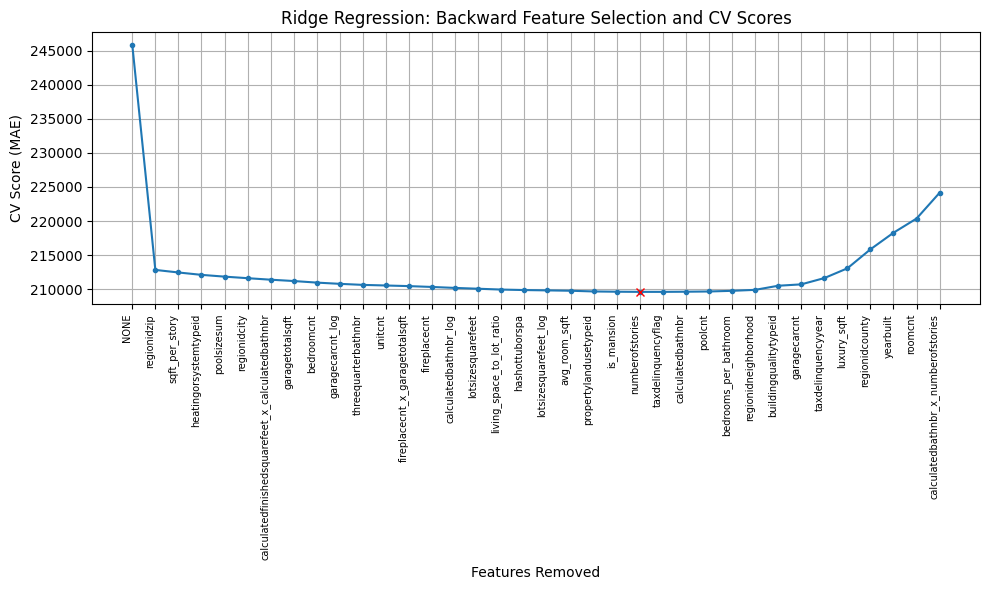

Best feature set: ['buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'garagecarcnt', 'poolcnt', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'yearbuilt', 'taxdelinquencyflag', 'taxdelinquencyyear', 'luxury_sqft', 'bedrooms_per_bathroom', 'calculatedbathnbr_x_numberofstories']
CV score (MAE): 209600.5589


In [23]:
# Backward Feature Selection - Ridge

model = Ridge(random_state=random_state)

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X_eng_train, y_eng_train, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Ridge Regression: Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (MAE)')

# plt.ylim(300000, 360000)

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (MAE):", np.around(best_backward_score, 4))

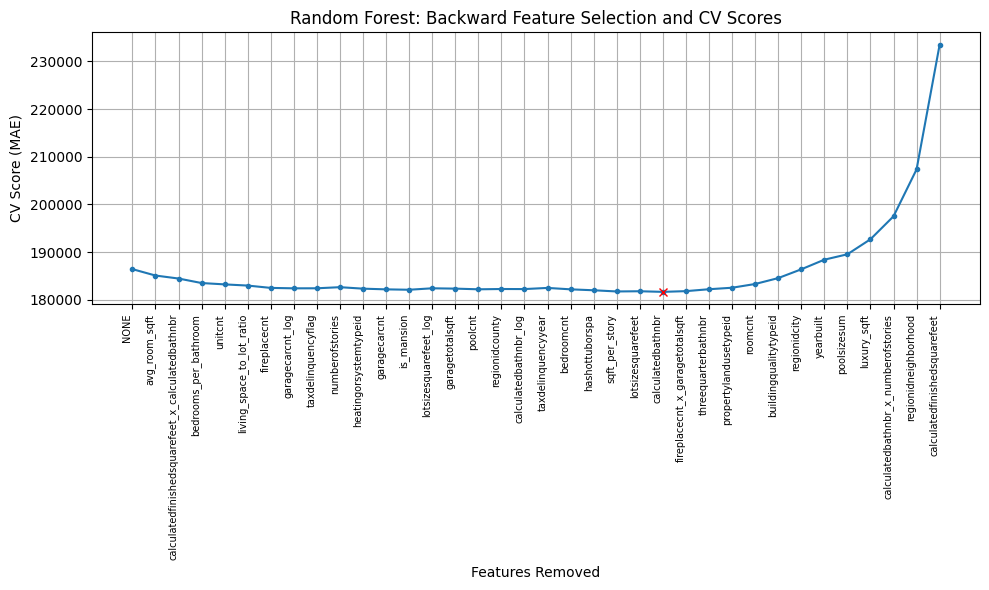

Best feature set: ['buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'poolsizesum', 'propertylandusetypeid', 'regionidcity', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'threequarterbathnbr', 'yearbuilt', 'luxury_sqft', 'fireplacecnt_x_garagetotalsqft', 'calculatedbathnbr_x_numberofstories']
CV score (MAE): 181638.3729


In [25]:
# Backward Feature Selection - Random Forest

model = RandomForestRegressor(random_state=random_state)

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X_eng_train, y_eng_train, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Random Forest: Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (MAE)')

# plt.ylim(300000, 360000)

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (MAE):", np.around(best_backward_score, 4))

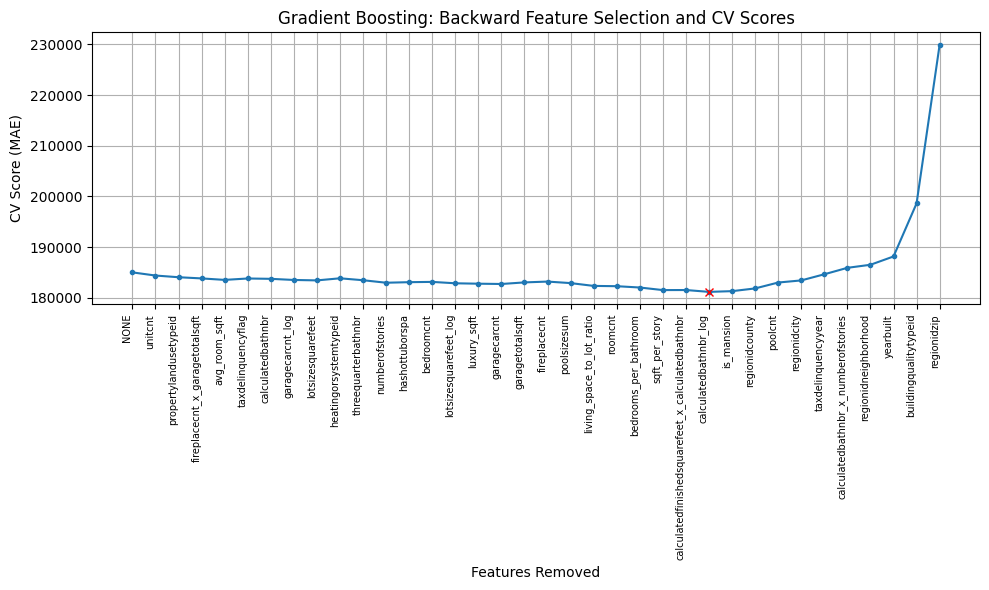

Best feature set: ['buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'poolcnt', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'yearbuilt', 'taxdelinquencyyear', 'is_mansion', 'calculatedbathnbr_x_numberofstories']
CV score (MAE): 181185.9407


In [27]:
# Backward Feature Selection - Gradient Boosting

model = GradientBoostingRegressor(random_state=random_state)

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X_eng_train, y_eng_train, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Gradient Boosting: Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (MAE)')

# plt.ylim(300000, 360000)

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (MAE):", np.around(best_backward_score, 4))

#### Best Perfoming Subsets for Each Model

Ridge Regression

In [16]:
ridge_set = df_engineered[['buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'garagecarcnt', 'poolcnt', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'yearbuilt', 'taxdelinquencyflag', 'taxdelinquencyyear', 'luxury_sqft', 'bedrooms_per_bathroom', 'calculatedbathnbr_x_numberofstories']]

In [17]:
best_ridge_set = Ridge(random_state=random_state)
best_ridge_scores = cross_validate(best_ridge_set, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

ridge_mean_train_mae = np.mean(-best_ridge_scores['train_score'])
ridge_mean_mae = np.mean(-best_ridge_scores['test_score'])
ridge_std_mae = np.std(-best_ridge_scores['test_score'])

print(f"Mean Train MAE Score: ${ridge_mean_train_mae:,.2f}")
print(f"Mean CV MAE Score: ${ridge_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${ridge_std_mae:,.2f}")

Mean Train MAE Score: $209,045.50
Mean CV MAE Score: $236,831.33
STD CV MAE Score: $47,231.01


Random Forest

In [18]:
random_forest_set = df_engineered[['buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'poolsizesum', 'propertylandusetypeid', 'regionidcity', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'threequarterbathnbr', 'yearbuilt', 'luxury_sqft', 'fireplacecnt_x_garagetotalsqft', 'calculatedbathnbr_x_numberofstories']]

In [19]:
best_rf_set = RandomForestRegressor(random_state=random_state)
best_rf_scores = cross_validate(best_rf_set, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

rf_mean_train_mae = np.mean(-best_rf_scores['train_score'])
rf_mean_mae = np.mean(-best_rf_scores['test_score'])
rf_std_mae = np.std(-best_rf_scores['test_score'])

print(f"Mean Train MAE Score: ${rf_mean_train_mae:,.2f}")
print(f"Mean CV MAE Score: ${rf_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${rf_std_mae:,.2f}")

Mean Train MAE Score: $69,031.64
Mean CV MAE Score: $184,979.41
STD CV MAE Score: $11,173.44


Gradient Boosting

In [20]:
gradient_boosting_set = df_engineered[['buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'poolcnt', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'yearbuilt', 'taxdelinquencyyear', 'is_mansion', 'calculatedbathnbr_x_numberofstories']]

In [22]:
best_gb_set = GradientBoostingRegressor(random_state=random_state)
best_gb_scores = cross_validate(best_gb_set, X_train_scaled, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

gb_mean_train_mae = np.mean(-best_gb_scores['train_score'])
gb_mean_mae = np.mean(-best_gb_scores['test_score'])
gb_std_mae = np.std(-best_gb_scores['test_score'])

print(f"Mean Train MAE Score: ${gb_mean_train_mae:,.2f}")
print(f"Mean CV MAE Score: ${gb_mean_mae:,.2f}")
print(f"STD CV MAE Score: ${gb_std_mae:,.2f}")

Mean Train MAE Score: $147,718.04
Mean CV MAE Score: $185,165.87
STD CV MAE Score: $10,869.67


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

#### Ridge

In [ ]:
params_dist = {

}

ridge_model = Ridge(random_state=random_state)

ridge_search = GridSearchCV()

### Random Forest

In [ ]:
params_dist = {

}

rf_model = RandomForestRegressor(random_state=random_state)

rf_search = GridSearchCV()

### Gradient Boosting

In [ ]:
params_dist = {

}

gb_model = GradientBoostingRegressor(random_state=random_state)

gb_search = GridSearchCV()

### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [ ]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here